In [1]:
from pathlib import Path
import pandas as pd
import numpy as np

# Viz
import seaborn as sns
import glasbey # for colorblind palette
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from matplotlib.colors import LinearSegmentedColormap, PowerNorm
from matplotlib.patches import Wedge

# ML
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, cross_val_score
import umap


c:\git\datascience-capstone\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_parquet(Path("../../data/processed/preprocessed.parquet"))

In [3]:
element_cols = [c for c in df.columns if c not in [
    'stub_id', 'particle_id', 'relevance_class',
    'merged_relevance_class', 'final_class', 'label', 'target'
]]

print(f"Particles: {len(df):,}")
print(f"Element features: {len(element_cols)}")
print(f"\nLabel distribution:")
print(df['label'].value_counts())

Particles: 2,294,985
Element features: 27

Label distribution:
label
Non_GSR    1216039
GSR        1078946
Name: count, dtype: int64


In [4]:
binary = df[df['label'].isin(['GSR', 'Non_GSR'])]

__PCA__

In [5]:
X_vis = binary[element_cols].fillna(0).values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

__UMAP__

In [6]:
# Sample 10% to save my laptop  :)
sample, _ = train_test_split(
    binary, 
    train_size=0.1, 
    stratify=binary['label'], # stratify to maintain class balance
    random_state=42
)

f"Sample size: {len(sample):,}"

'Sample size: 229,498'

In [7]:
X_sample = sample[element_cols].fillna(0).values
umap_scaler = StandardScaler()
X_scaled_umap = umap_scaler.fit_transform(X_sample)

In [8]:
reducer = umap.UMAP(
    n_neighbors=15, # balance local vs. global structure
    min_dist=0.1, # tightness of clusters
    n_components=2, # 2D viz
    metric='euclidean', # default measuring technique for continuous data
    random_state=42, # reproducibility: keep at 42 for comparing w/ different params & ambiguous class overlay
    low_memory=True
)
X_umap = reducer.fit_transform(X_scaled_umap)

c:\git\datascience-capstone\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [9]:
# kNN classification accuracy
# Tests whether neighbors in the embedding share labels
X_umap_np = np.array(X_umap)
knn = KNeighborsClassifier(n_neighbors=15)
labels = np.array(sample['label'].values)
knn_umap = cross_val_score(knn, X_umap_np, labels, cv=5, scoring='accuracy').mean()

f"kNN classification accuracy: {knn_umap * 100:.1f}%"

'kNN classification accuracy: 93.9%'

C:\Users\bkoco\AppData\Local\Temp\ipykernel_31820\2946807793.py:148: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(loc='lower right', bbox_to_anchor=(0.97, 0.14),


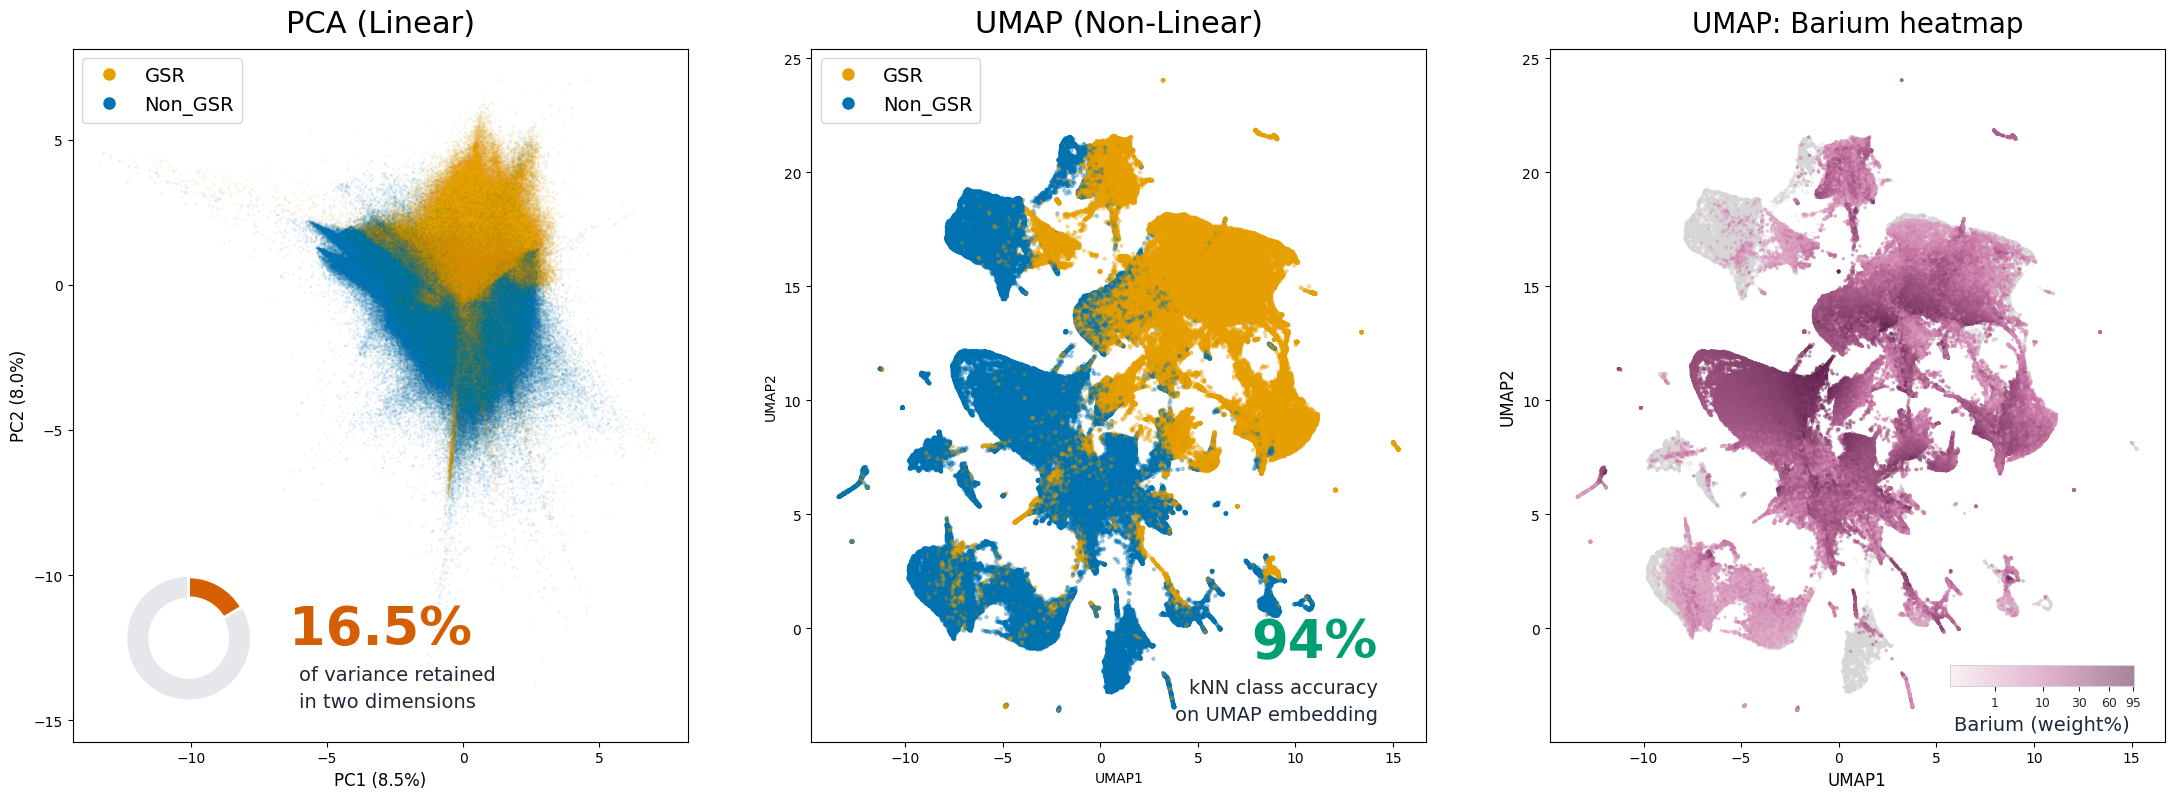

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(27, 9))

# color-blind friendly
GSR_COLOR = "#E69F00"
NON_GSR_COLOR = "#0072B2"
VARIANCE_COLOR = '#D55E00' # vermillion
NEUTRAL_GRAY_COLOR = '#E5E7EB' # neutral gray
INK_COLOR = '#1F2937' # near-black for caption text
KNN_COLOR = '#009E73'
ZERO_BA_COLOR = '#D6D6D6'

pca_colors = binary['label'].map({'GSR': GSR_COLOR, 'Non_GSR': NON_GSR_COLOR}).values
umap_colors = sample["label"].map({'GSR': GSR_COLOR, 'Non_GSR': NON_GSR_COLOR}).values
ba_cmap = LinearSegmentedColormap.from_list(
    'ba_ramp',
    [(0.00, '#F5E6EE'), (0.5, '#CC79A7'), (1.00, '#5C1F4A')],
)

## -- Axes[0]: PCA -- ##

axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=pca_colors, alpha=0.05, s=1, rasterized=True)
axes[0].set_title('PCA (Linear)', fontsize=22, pad=12)
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})', fontsize=12)
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})', fontsize=12)

total_var = pca.explained_variance_ratio_[0] + pca.explained_variance_ratio_[1]

fig_w_in, fig_h_in = fig.get_size_inches()
DONUT_DIAM_IN = 1.35   # tweak this to make the donut larger/smaller
donut_w_frac = DONUT_DIAM_IN / fig_w_in
donut_h_frac = DONUT_DIAM_IN / fig_h_in

# Donut for Variance (lower-left)
parent_bbox = axes[0].get_position()
donut_x = parent_bbox.x0 + 0.018
donut_y = parent_bbox.y0 + 0.04

donut_ax = fig.add_axes([donut_x, donut_y, donut_w_frac, donut_h_frac])
donut_ax.set_aspect('equal')
donut_ax.axis('off')
donut_ax.set_xlim(-1.1, 1.1)
donut_ax.set_ylim(-1.1, 1.1)

# Full ring
donut_ax.add_patch(Wedge(
    center=(0, 0), r=1.0, theta1=0, theta2=360,
    width=0.34, facecolor=NEUTRAL_GRAY_COLOR, edgecolor='none', zorder=1,
))

# Retained slice starts at top, sweeps clockwise
sweep = total_var * 360
donut_ax.add_patch(Wedge(
    center=(0, 0), r=1.0, theta1=90 - sweep, theta2=90,
    width=0.34, facecolor=VARIANCE_COLOR, edgecolor='white', linewidth=2, zorder=2,
))

# PCA Variance percentage & text caption
num_x = donut_x + donut_w_frac + 0.012
num_y_center = donut_y + donut_h_frac / 2

fig.text(
    num_x, num_y_center + 0.01,
    f'{total_var:.1%}',
    fontsize=38, fontweight='bold', color=VARIANCE_COLOR,
    ha='left', va='center',
)
fig.text(
    num_x + 0.004, num_y_center - 0.04,
    'of variance retained',
    fontsize=14, color=INK_COLOR, ha='left', va='center',
)
fig.text(
    num_x + 0.004, num_y_center - 0.07,
    'in two dimensions',
    fontsize=14, color=INK_COLOR, ha='left', va='center',
)
# legend for PCA binary labels
pca_handles = [
    mlines.Line2D([], [], color=GSR_COLOR, marker='o', linestyle='None', markersize=8, label='GSR'),
    mlines.Line2D([], [], color=NON_GSR_COLOR, marker='o', linestyle='None', markersize=8, label='Non_GSR')
]
pca_legend = axes[0].legend(handles=pca_handles, loc='upper left', fontsize=14, frameon=True,
          edgecolor='#D1D5DB', framealpha=0.95)
# pca_legend.set_title("Label", prop={'size': 12, 'weight': 'bold'})
title = pca_legend.get_title()

## -- Axes[1]:UMAP -- ##
le_umap = LabelEncoder()
class_encoded = le_umap.fit_transform(sample["final_class"])

axes[1].scatter(X_umap[:, 0], X_umap[:, 1], c=umap_colors, alpha=0.3, s=5)
axes[1].set_title("UMAP (Non-Linear)", fontsize=22, pad=12)
axes[1].set_xlabel("UMAP1")
axes[1].set_ylabel("UMAP2")

# umap legend
umap_handles = [
    mlines.Line2D([], [], color=GSR_COLOR, marker='o', linestyle='None',
                  markersize=8, label='GSR'),
    mlines.Line2D([], [], color=NON_GSR_COLOR, marker='o', linestyle='None',
                  markersize=8, label='Non_GSR'),
]
axes[1].legend(handles=umap_handles, loc='upper left', fontsize=14,
               frameon=True, edgecolor='#D1D5DB', framealpha=0.95)

# kNN classification accuracy
parent_bbox_umap = axes[1].get_position()
knn_x = parent_bbox_umap.x1 - 0.018
knn_y_center = parent_bbox_umap.y0 + 0.10

fig.text(knn_x, knn_y_center + 0.01, f'{knn_umap:.0%}',
         fontsize=38, fontweight='bold', color=KNN_COLOR,
         ha='right', va='center')
fig.text(knn_x, knn_y_center - 0.04, 'kNN class accuracy',
         fontsize=14, color=INK_COLOR, ha='right', va='center')
fig.text(knn_x, knn_y_center - 0.07, 'on UMAP embedding',
         fontsize=14, color=INK_COLOR, ha='right', va='center')

## -- Axes[2]: UMAP with Barium Overlay -- ##
ba_values = sample['ba'].values
zero_mask = ba_values == 0
nonzero_mask = ~zero_mask

axes[2].scatter(X_umap[zero_mask, 0], X_umap[zero_mask, 1],
                c=ZERO_BA_COLOR, alpha=0.30, s=4, rasterized=True, edgecolors='none')

norm = PowerNorm(gamma=0.3, vmin=0.1, vmax=ba_values.max())
sc = axes[2].scatter(X_umap[nonzero_mask, 0], X_umap[nonzero_mask, 1],
                     c=ba_values[nonzero_mask], cmap=ba_cmap, norm=norm,
                     alpha=0.55, s=6, rasterized=True, edgecolors='none')

axes[2].set_title('UMAP: Barium heatmap', fontsize=20, pad=12)
axes[2].set_xlabel('UMAP1', fontsize=12)
axes[2].set_ylabel('UMAP2', fontsize=12)

# cbar_ax = axes[2].inset_axes([0.02, 0.92, 0.30, 0.03])
cbar_ax = axes[2].inset_axes([0.65, 0.08, 0.30, 0.03])
cbar = fig.colorbar(sc, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Barium (weight%)', fontsize=14, color=INK_COLOR, labelpad=4)
cbar.ax.tick_params(labelsize=9, colors=INK_COLOR)
cbar.set_ticks([1, 10, 30, 60, 95])
cbar.outline.set_edgecolor('#D1D5DB')

axes[2].scatter([], [], c=ZERO_BA_COLOR, s=40, alpha=0.7,
                edgecolors='none')
# axes[2].legend(loc='lower right', bbox_to_anchor=(0.02, 0.86),
#                fontsize=14, frameon=False)
axes[2].legend(loc='lower right', bbox_to_anchor=(0.97, 0.14),
               fontsize=14, frameon=False)

# plt.tight_layout()
# plt.savefig('figures/pca_vs_umap.png', bbox_inches='tight')
plt.show()